Final Project - Anikeenko_Ana



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#The main Data set:

df_bird_strikes=pd.read_csv ('Bird_strikes.csv')
df_bird_strikes.head (22)
#df_bird_strikes.tail (5)
#df_bird_strikes.sample (10)

,RecordID,AircraftType,AirportName,AltitudeBin,MakeModel,NumberStruck,NumberStruckActual,Effect,FlightDate,Damage,...,RemainsSentToSmithsonian,Remarks,WildlifeSize,ConditionsSky,WildlifeSpecies,PilotWarned,Cost,Altitude,PeopleInjured,IsAircraftLarge?
0,202152,Airplane,LAGUARDIA NY,"(1000, 2000]",B-737-400,Over 100,859,Engine Shut Down,11/23/00 0:00,Caused damage,...,False,FLT 753. PILOT REPTD A HUNDRED BIRDS ON UNKN T...,Medium,No Cloud,Unknown bird - medium,N,"30,736",1500,0,Yes
1,208159,Airplane,DALLAS/FORT WORTH INTL ARPT,"(-1, 0]",MD-80,Over 100,424,NaN,7/25/01 0:00,Caused damage,...,False,102 CARCASSES FOUND. 1 LDG LIGHT ON NOSE GEAR ...,Small,Some Cloud,Rock pigeon,Y,0,0,0,No
2,207601,Airplane,LAKEFRONT AIRPORT,"(30, 50]",C-500,Over 100,261,NaN,9/14/01 0:00,No damage,...,False,FLEW UNDER A VERY LARGE FLOCK OF BIRDS OVER AP...,Small,No Cloud,European starling,N,0,50,0,No
3,215953,Airplane,SEATTLE-TACOMA INTL,"(30, 50]",B-737-400,Over 100,806,Precautionary Landing,9/5/02 0:00,No damage,...,False,"NOTAM WARNING. 26 BIRDS HIT THE A/C, FORCING A...",Small,Some Cloud,European starling,Y,0,50,0,Yes
4,219878,Airplane,NORFOLK INTL,"(30, 50]",CL-RJ100/200,Over 100,942,NaN,6/23/03 0:00,No damage,...,False,NO DMG REPTD.,Small,No Cloud,European starling,N,0,50,0,No
5,218432,Airplane,GUAYAQUIL/S BOLIVAR,"(-1, 0]",A-300,Over 100,537,NaN,7/24/03 0:00,No damage,...,False,NO DMG. BIRD REMAINS ON F/O WINDSCREEN.,Small,No Cloud,Unknown bird - small,N,0,0,0,No
6,221697,Airplane,NEW CASTLE COUNTY,"(100, 200]",LEARJET-25,Over 100,227,Other,8/17/03 0:00,Caused damage,...,True,NaN,Small,No Cloud,European starling,N,"1,481,711",150,0,No
7,236635,Airplane,WASHINGTON DULLES INTL ARPT,"(50, 100]",A-320,Over 100,320,Other,3/1/06 0:00,Caused damage,...,False,WS ASSISTED IN CLEAN-UP OF 273 STARLINGS AND 1...,Small,Some Cloud,European starling,Y,"1,483,141",100,0,No
8,207369,Airplane,ATLANTA INTL,"(-1, 0]",DC-9-30,2 to 10,9,Aborted Take-off,1/6/00 0:00,No damage,...,False,NaN,Small,Some Cloud,Rock pigeon,N,0,0,0,No
9,204371,Airplane,ORLANDO SANFORD INTL AIRPORT,"(-1, 0]",A-330,2 to 10,4,NaN,1/7/00 0:00,No damage,...,False,FLT 057,Small,Some Cloud,Unknown bird - small,N,0,0,0,No


In [3]:
F=df_bird_strikes.ConditionsSky.unique()
print (F)

df_bird_strikes.nunique()

['No Cloud' 'Some Cloud' 'Overcast']


,0
RecordID,25429
AircraftType,1
AirportName,1109
AltitudeBin,13
MakeModel,324
NumberStruck,4
NumberStruckActual,106
Effect,4
FlightDate,4225
Damage,2


In [4]:
df_bird_strikes.isnull().sum()

,0
RecordID,0
AircraftType,0
AirportName,0
AltitudeBin,0
MakeModel,0
NumberStruck,0
NumberStruckActual,0
Effect,23351
FlightDate,0
Damage,0


/tmp/ipykernel_1551/3509060873.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_bird_strikes['FlightDate'] = pd.to_datetime(df_bird_strikes['FlightDate'])




Year
2009    12.8
2010    12.3
2011    11.6
2007     9.0
2008     8.9
2006     8.5
2005     7.3
Name: RecordID, dtype: float64


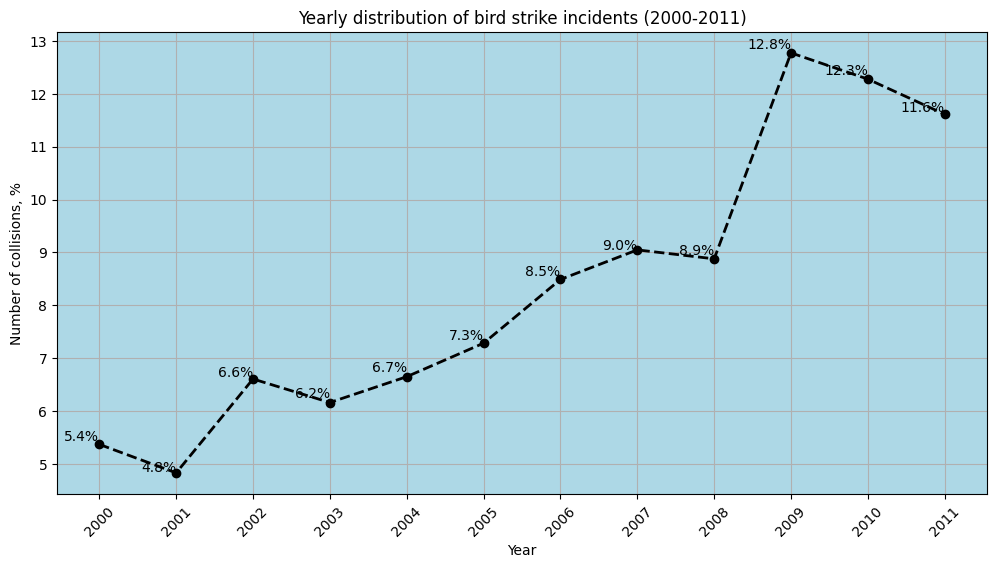

In [5]:
# Key-factor no.1: The more flights - more collisions.
"""
It goes without saying that birds and aircraft share our nation’s airspace,
and the risk of collision with birds is a reality that needs to be taken seriously,
especially with the increase in both the populations of large birds and aircraft traffic.
Because planes fly at such high speed, the damage from collision with birds,
especially large birds, or groups of birds that enter an engine or windshield, can be devastating.
"""

df_bird_strikes['FlightDate'] = pd.to_datetime(df_bird_strikes['FlightDate'])
df_bird_strikes['Year'] = df_bird_strikes['FlightDate'].dt.year
df_bird_strikes['Month'] = df_bird_strikes['FlightDate'].dt.month
print ()
print ();


Year_of_strikes_1 = (df_bird_strikes
 .groupby ('Year')
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100).head (7)
Year_of_strikes_r1 = Year_of_strikes_1.round (1)
print (Year_of_strikes_r1);



year_counts = df_bird_strikes.groupby('Year')['RecordID'].count() / 25429*100
plt.figure(figsize=(12, 6))
year_counts.plot(kind='line', lw=2, grid='True', c='black', linestyle='--', marker='o',
                 ylabel='Number of collisions, %', xlabel='Year',
                 title="Yearly distribution of bird strike incidents (2000-2011)")
year_counts_r = year_counts.round (1)
for year, count in year_counts_r.items():
    plt.text(year, count, str(count)+'%', ha='right', va='bottom')
plt.xticks(rotation=45)
plt.gca().set_facecolor('lightblue')
plt.xticks (np.arange(2000, 2012,1))
plt.show()

MakeModel
B-737-700       9.8
B-737-300       9.1
CL-RJ100/200    7.7
A-320           4.7
A-319           3.9
B-757-200       3.9
EMB-145         3.9
B-737-800       2.7
MD-82           2.5
B-717-200       2.3
Name: RecordID, dtype: float64


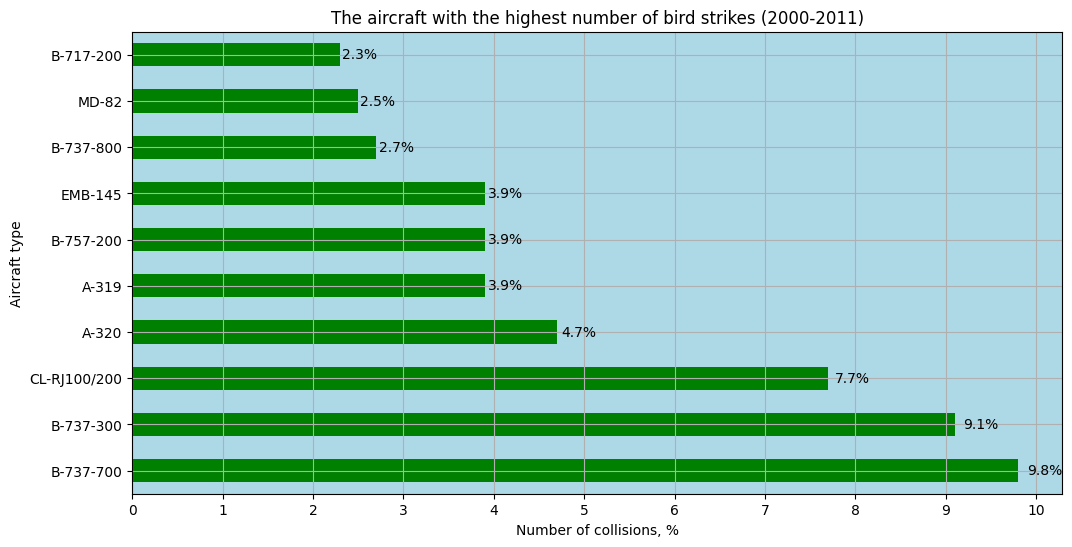

In [6]:
# The aircraft with the highest number of bird strikes

number_of_strikes = (df_bird_strikes
 .groupby ('MakeModel')
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100).head (10)
number_of_strikes_r = number_of_strikes.round (1)
print (number_of_strikes_r);


plt.figure(figsize=(12,6))
number_of_strikes_r.plot.barh(color='green', grid = 'True', ylabel='Aircraft type', xlabel='Number of collisions, %',
                              title = "The aircraft with the highest number of bird strikes (2000-2011)")


for index, value in enumerate(number_of_strikes_r):
    # Adjust label position based on bar length (optional)
    x_pos = value + (value * 0.01)  # Offset label slightly to the right
    plt.text(x_pos, index, str(value)+"%", va='center')  # Vertical alignment


plt.gca().set_facecolor('lightblue')
plt.xticks (np.arange(0,11,1))
plt.show();

Boeing 737 (с 1967-)
Boeing за полвека истории продал столько В737, что сегодня записан в Книгу рекордов Гиннеса. 10-тысячный Boeing 737 сошел с конвейера весной 2018 года и отправился в авиакомпанию Southwest Airlines. В737 эксплуатируется более чем 5 тыс. авиакомпаний в 200 странах мира, и в доковидной обстановке в небе могло одновременно находиться около 1,2 тыс. этих самолетов.
С такими цифрами В737 остается самым продаваемым современным самолетом в мире.


Airbus A320 (1987-)
Семейство A320 существует не так давно, как Boeing 737, но является ему серьезным конкурентом.
По данным Airbus за все время было поставлено 9626 самолетов A320 во всех модификациях. Эта модель оснащена передовыми технологиями, включая электронную систему управления полетом (fly-by-wire), что обеспечивает более плавное и безопасное управление.


CL-RJ100/200    7.7
Bombardier CRJ (Canadair Regional Jet). Первый полёт самолёт совершил 10 мая 1991 года. CRJ-100 стал первым самолётом современного уровня среди 50-местных машин. По скорости самолёт можно сравнивать и с более крупными машинами, в то время как его экономичность вполне соответствует классу. Семейство состоит из нескольких модификаций, отличающихся длиной фюзеляжа и дальностью полёта. Самолёт изначально назывался Bombardier CRJ и был переименован после покупки программы CRJ компанией Mitsubishi в 2020 году.


MakeModel
A-319           0.3
A-320           0.5
B-737-300       0.6
B-737-700       0.5
B-757-200       0.4
CL-RJ100/200    0.5
EMB-145         0.2
Name: RecordID, dtype: float64
MakeModel
A-319           3.6
A-320           4.2
B-737-300       8.5
B-737-700       9.3
B-757-200       3.5
CL-RJ100/200    7.2
EMB-145         3.7
Name: RecordID, dtype: float64


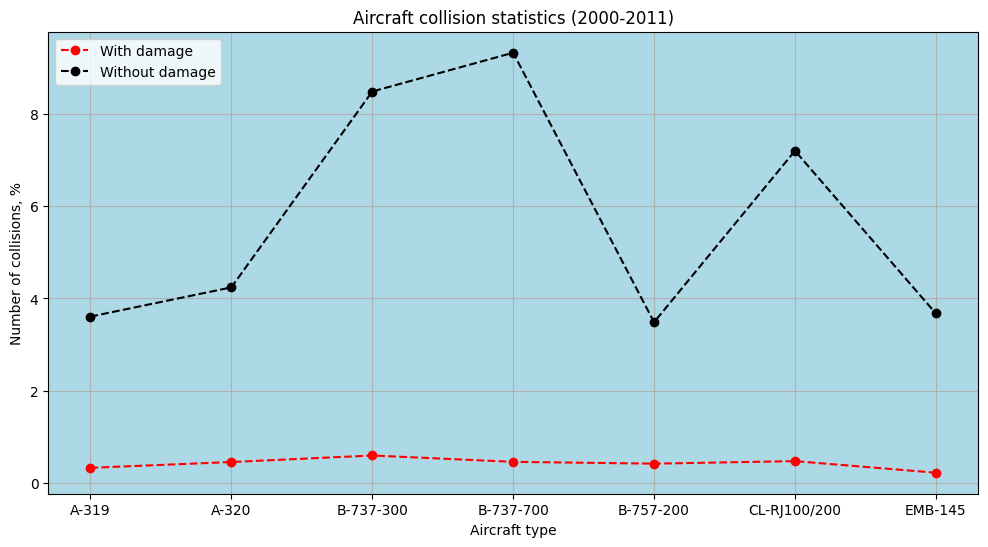

In [7]:
df_bird_strikes['Cost'] = pd.to_numeric(df_bird_strikes['Cost'], errors='coerce')
#boolean mask for Top 7 aircrafts with the highest number of bird strikes:
df_Aircraft_top = df_bird_strikes.loc[(df_bird_strikes.MakeModel =='B-737-700')|(df_bird_strikes.MakeModel =='B-737-300')|(df_bird_strikes.MakeModel =='CL-RJ100/200')|
                                      (df_bird_strikes.MakeModel =='A-320')|(df_bird_strikes.MakeModel =='A-319')|(df_bird_strikes.MakeModel =='B-757-200')|
                                      (df_bird_strikes.MakeModel =='EMB-145')]
df_damage_Y = df_Aircraft_top.loc[(df_bird_strikes.Damage =='Caused damage')]
df_damage_N = df_Aircraft_top.loc[(df_bird_strikes.Damage =='No damage')]

# with damage
number_top_damage = (df_damage_Y
 .groupby (['MakeModel'])
 ['RecordID']
 .count()/25429*100)
number_top_damage_r = number_top_damage.round(1)
print (number_top_damage_r);

# without damage
number_top_nodamage = (df_damage_N
 .groupby (['MakeModel'])
 ['RecordID']
 .count()/25429*100)
number_top_nodamage_r = number_top_nodamage.round(1)
print (number_top_nodamage_r);


plt.figure(figsize=(12, 6))
number_top_damage.plot.line(color='red', grid=True, label='With damage', linestyle='--', marker='o')
number_top_nodamage.plot.line(color='black', grid=True, label='Without damage', linestyle='--', marker='o')

plt.ylabel('Number of collisions, %')
plt.xlabel('Aircraft type')
plt.title("Aircraft collision statistics (2000-2011)")
plt.legend(loc='upper left')
plt.gca().set_facecolor('lightblue')
plt.show()


MakeModel
B-737-700       23260.0
B-737-300       11718.0
B-737-800        3758.0
CL-RJ100/200     3637.0
PA-28            3305.0
A-320            2685.0
B-727-200        2513.0
Name: Cost, dtype: float64




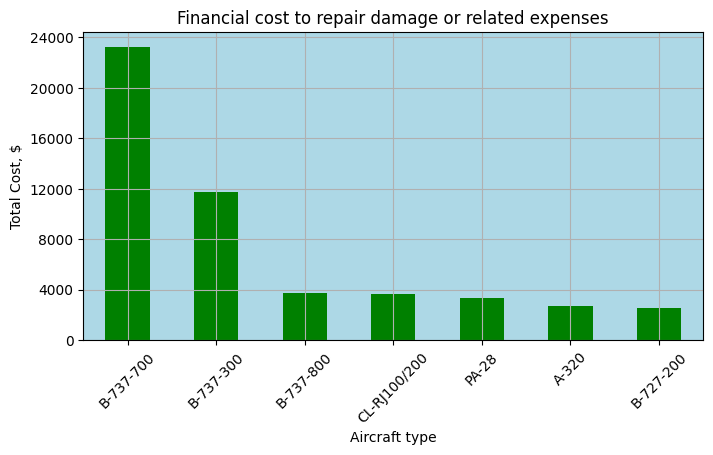

In [8]:
# Total cost on Aircraft after bird strike

cost_top_damage = df_bird_strikes.groupby (['MakeModel'])['Cost'].sum().sort_values(ascending=False).head (7)
print (cost_top_damage)
print()
print();

plt.figure(figsize=(8, 4))
cost_top_damage.plot.bar(color='green', grid=True)

plt.ylabel('Total Cost, $')
plt.xlabel('Aircraft type')
plt.title("Financial cost to repair damage or related expenses")
#plt.legend(loc='upper left')
plt.gca().set_facecolor('lightblue')
plt.yticks (np.arange(0, 25000, 4000))
plt.xticks(rotation=45)
plt.show()

In [9]:
# Let's find out in which airport the most collisions have occurred (Top 10).
# 5. Dallas Fortworth International Airport - Area: 69.93 km².

Num_Collisions_Airport = (df_bird_strikes
 .groupby ('MakeModel')
 ['Cost']
 .count()
 .sort_values(ascending=False)/25429*100).head (10)
print(Num_Collisions_Airport)
print()
print()
print();


MakeModel
B-737-700       9.685792
B-737-300       8.962209
CL-RJ100/200    7.577962
A-320           4.620709
A-319           3.881395
EMB-145         3.873530
B-757-200       3.802745
B-737-800       2.603327
MD-82           2.497149
B-717-200       2.257265
Name: Cost, dtype: float64








Altitude
0       38.7
100      5.3
50       5.0
200      3.9
10       3.5
500      3.5
1000     3.2
Name: RecordID, dtype: float64



Altitude  FlightPhase 
0         Landing Roll    19.8
          Take-off run    18.5
100       Approach         3.5
50        Approach         3.1
200       Approach         2.8
500       Approach         2.6
1000      Approach         2.4
Name: RecordID, dtype: float64



Altitude
0-50         53.8
1001-2000     7.1
501-1000      7.0
51-100        6.2
201-400       5.1
101-200       5.1
2001-3000     4.6
Name: RecordID, dtype: float64





/tmp/ipykernel_1551/2103092253.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby (df_AltitudeBins)


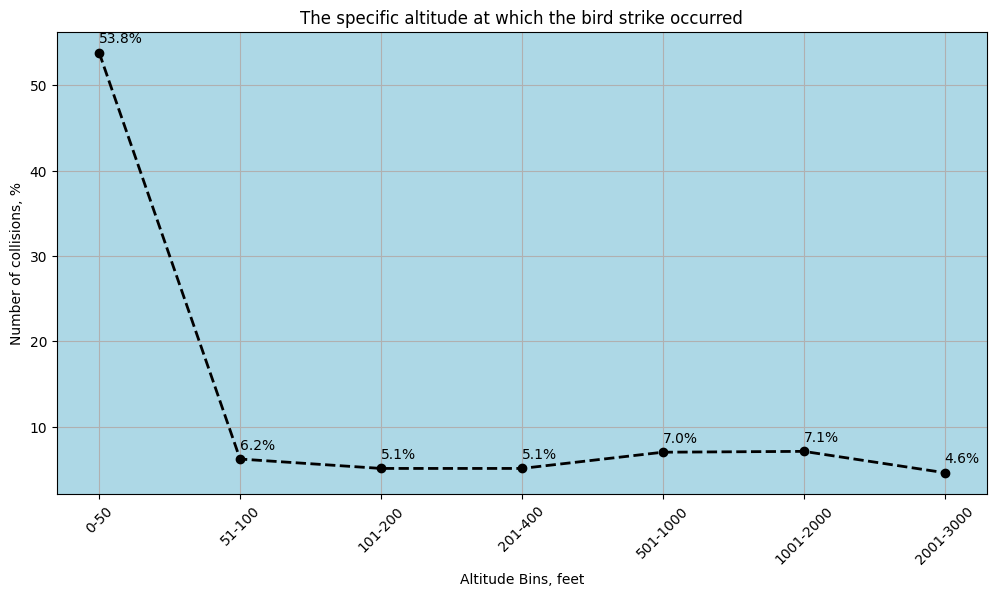

In [10]:
# Key-factor no.2: Altitude.
# Altitude: The specific altitude at which the bird strike occurred, typically in feet.
"""
Although collisions between birds and airplanes can occur at any time,
the majority are relatively low altitudes during take-off and landing.
During flight, many planes, especially commercial jets, fly at higher altitudes than birds.

According to the International Civil Aviation Organization, 90% of bird strikes happen near airports.
In general, this is while aircraft are taking off or landing,
or flying at lower altitudes where most bird activity occurs.
"""
#AltitudeBins
df_AltitudeBins = pd.cut(df_bird_strikes.Altitude,
                         bins = [-1,50,100,200,400,500,1000,2000,3000,5000,18000],
                         labels = ['0-50','51-100','101-200','201-400','401-500', '501-1000', '1001-2000', '2001-3000','3001-5000','5001-18000'])
print()
print()
print();


Num_Collisions_Alt = (df_bird_strikes
 .groupby ('Altitude')
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100).head (7)
Num_Collisions_Alt_r = Num_Collisions_Alt.round(1)
print(Num_Collisions_Alt_r)
print()
print()
print();


Num_Collisions_Alt_Phase = (df_bird_strikes
 .groupby (['Altitude','FlightPhase'])
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100).head (7)
Num_Collisions_Alt_Phase_r = Num_Collisions_Alt_Phase.round(1)
print(Num_Collisions_Alt_Phase_r)
print()
print()
print();


# Let's find at what altitudes the highest number of collisions occure.
Num_Collisions_Altb = (df_bird_strikes
 .groupby (df_AltitudeBins)
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100).head (7)
Num_Collisions_Altb_r = Num_Collisions_Altb.round(1)
print(Num_Collisions_Altb_r)
print()
print()
print();

Num_Collisions_Altb_r = Num_Collisions_Altb_r.sort_index()
plt.figure(figsize=(12, 6))
Num_Collisions_Altb_r.plot.line(lw = 2, grid = 'True', c = 'black', linestyle = '--', marker = 'o',
                              ylabel='Number of collisions, %', xlabel='Altitude Bins, feet',
                              title = "The specific altitude at which the bird strike occurred")

# Get the x-axis values (altitude bins)
x_values = Num_Collisions_Altb_r.index

# Add annotations to each data point
for i, (x, y) in enumerate(Num_Collisions_Altb_r.items()):
    plt.annotate(f"{y}%", xy=(i, y), xytext=(0, 5), textcoords="offset points", ha='left', va='bottom')

# Set the x-axis labels to altitude bins
plt.xticks(range(len(x_values)), x_values)
plt.xticks(rotation=45)
plt.gca().set_facecolor('lightblue')
plt.show();

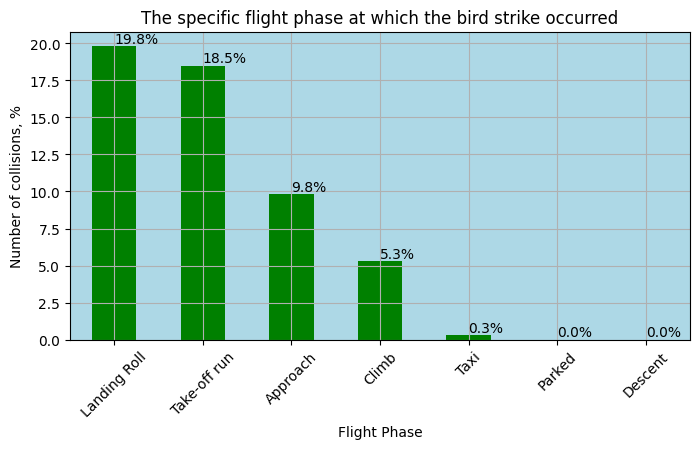

FlightPhase
Landing Roll    19.8
Take-off run    18.5
Approach         9.8
Climb            5.3
Taxi             0.3
Parked           0.0
Descent          0.0
Name: RecordID, dtype: float64




In [11]:
#boolean mask for Altitude (-1,50)
df_Alt_50 = df_bird_strikes.loc[(df_AltitudeBins == '0-50')]


Num_Collisions_Altitude_FlightPhase = (df_Alt_50
 .groupby(['FlightPhase'])
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100).head(7)
Num_Collisions_Altitude_FlightPhase_r=Num_Collisions_Altitude_FlightPhase.round(1)


plt.figure(figsize=(8, 4))
Num_Collisions_Altitude_FlightPhase_r.plot.bar (grid = 'True', color = 'green',
                                               ylabel='Number of collisions, %', xlabel='Flight Phase',
                                               title = "The specific flight phase at which the bird strike occurred")


for i, (x, y) in enumerate(zip(Num_Collisions_Altitude_FlightPhase_r.index, Num_Collisions_Altitude_FlightPhase_r.values)):
    plt.text(i, y, f"{y}%", ha='left', va='bottom')

plt.xticks(range(len(Num_Collisions_Altitude_FlightPhase_r.index)), Num_Collisions_Altitude_FlightPhase_r.index)
plt.gca().set_facecolor('lightblue')
plt.xticks(rotation=45)
plt.show()
print(Num_Collisions_Altitude_FlightPhase_r)
print()
print();

Month
8     14.6
9     13.4
7     12.9
10    11.9
5      9.1
6      8.2
4      7.2
11     7.1
3      4.8
12     4.0
1      3.7
2      3.0
Name: RecordID, dtype: float64





'\nplt.figure(figsize=(8, 6))\nMonth_of_strikes_2 = (df_bird_strikes\n .groupby ([\'FlightDate\'])\n [\'RecordID\']\n .count()/25429*100).plot.line(color=\'green\', ylabel=\'Number of collisions, %\', xlabel=\'Year, month of flight\', title = "Number of bird strikes by month.")'

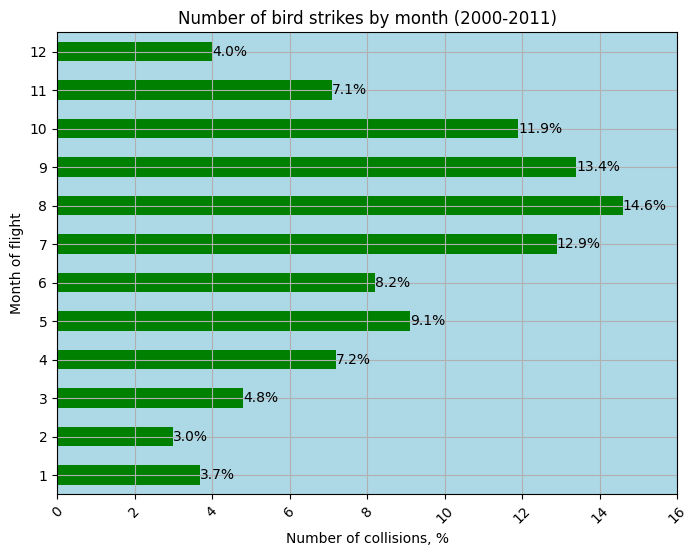

In [12]:
# Key-factor no.3: Migratory Bird Activity.
"""
Bird strike risk increases because of bird migration during the months of March through April, and August through November.
"""

plt.figure(figsize=(8, 6))
Month_of_strikes = (df_bird_strikes
 .groupby ('Month')
 ['RecordID']
 .count()/25429*100)
Month_of_strikes_r = Month_of_strikes.round(1);

Month_of_strikes_r.plot.barh(color='green', grid = 'True', ylabel='Month of flight', xlabel='Number of collisions, %', title = "Number of bird strikes by month (2000-2011)")

# Add labels to each bar
for index, value in enumerate(Month_of_strikes_r):
    plt.text(value, index, str(value)+'%', va='center')
plt.xticks (np.arange(0, 17, 2))
plt.gca().set_facecolor('lightblue');


Month_of_strikes_1 = (df_bird_strikes
 .groupby ('Month')
 ['RecordID']
 .count()
 .sort_values(ascending=False)/25429*100)
Month_of_strikes_1r = Month_of_strikes_1.round(1)
plt.xticks(rotation=45)
print (Month_of_strikes_1r)
print()
print()
print();


"""
plt.figure(figsize=(8, 6))
Month_of_strikes_2 = (df_bird_strikes
 .groupby (['FlightDate'])
 ['RecordID']
 .count()/25429*100).plot.line(color='green', ylabel='Number of collisions, %', xlabel='Year, month of flight', title = "Number of bird strikes by month.")"""



WildlifeSize
Large      8.2
Medium    23.3
Small     68.5
Name: RecordID, dtype: float64


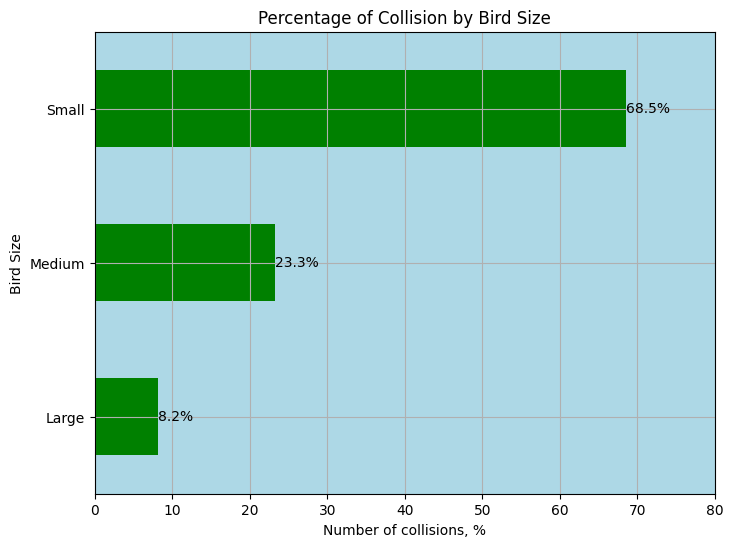

In [13]:
# Percentage of Collision by Bird Size.

plt.figure(figsize=(8, 6))
Birds_size = (df_bird_strikes
 .groupby ('WildlifeSize')
 ['RecordID']
 .count()/25429*100)
Birds_size_r = Birds_size.round(1)

Birds_size_r.plot.barh(color='green', grid = 'True', ylabel='Bird Size', xlabel='Number of collisions, %', title = "Percentage of Collision by Bird Size")

# Add labels to the bars
for index, value in enumerate(Birds_size_r):
    plt.text(value, index, str(value) + '%', va='center')
plt.xticks (np.arange(0, 90, 10))
plt.gca().set_facecolor('lightblue')

print (Birds_size_r);

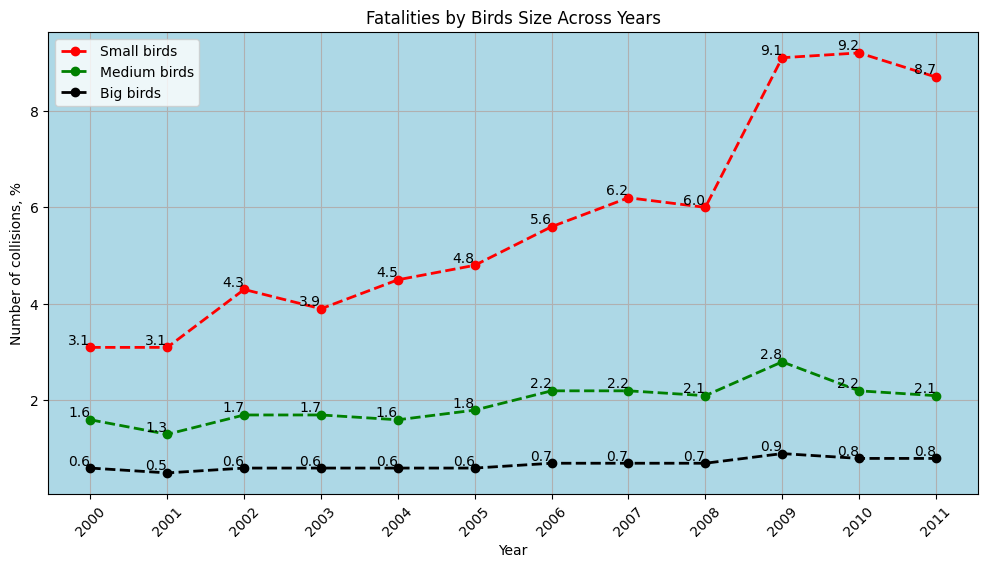

In [14]:
Mask_size_s = df_bird_strikes.loc[df_bird_strikes.WildlifeSize == 'Small']
Mask_size_m = df_bird_strikes.loc[df_bird_strikes.WildlifeSize == 'Medium']
Mask_size_l = df_bird_strikes.loc[df_bird_strikes.WildlifeSize == 'Large']

plt.figure(figsize=(12, 6))
axx = Mask_size_s.groupby('Year')['WildlifeSpecies'].count()/25429*100
axxx = axx.round(1)
ax = axxx.plot.line(lw=2, color = 'red', label='Small birds', grid = 'True', linestyle='--', marker='o',
                    title = "Fatalities by Birds Size Across Years",
                    ylabel = 'Number of collisions, %')

ay=(Mask_size_m.groupby ('Year')['WildlifeSpecies'].count()/25429*100)
ayy=ay.round(1)
ayy.plot.line (lw=2, grid = 'True',
                                                                               color='green',label='Medium birds',
                                                                               linestyle='--', marker='o', ax=ax)
az=(Mask_size_l.groupby ('Year')['WildlifeSpecies'].count()/25429*100)
azz=az.round(1)
azz.plot.line (lw=2, grid = 'True',
                                                                               color='black', label='Big birds',
                                                                               linestyle='--', marker='o', ax=ax)
# small birds:
for y1, c1 in axxx.items():
    plt.text(y1, c1, str(c1), ha='right', va='bottom')

# medium birds:
for y2, c2 in ayy.items():
    plt.text(y2, c2, str(c2), ha='right', va='bottom')

# big birds:
for y3, c3 in azz.items():
    plt.text(y3, c3, str(c3), ha='right', va='bottom')

plt.xticks(rotation=45)
plt.gca().set_facecolor('lightblue')
plt.xticks (np.arange(2000, 2012,1))
plt.legend(loc='upper left')
plt.show();

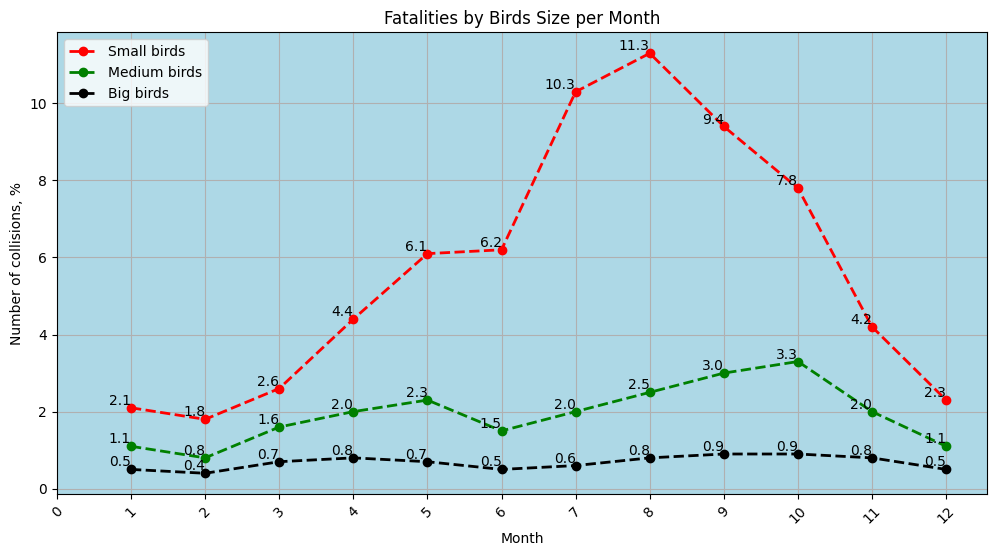

In [15]:
plt.figure(figsize=(12, 6))
axx = Mask_size_s.groupby('Month')['WildlifeSpecies'].count()/25429*100
axxx = axx.round(1)
ax = axxx.plot.line(lw=2, color = 'red', label='Small birds', grid = 'True', linestyle='--', marker='o',
                    title = "Fatalities by Birds Size per Month",
                    ylabel = 'Number of collisions, %')

ay=(Mask_size_m.groupby ('Month')['WildlifeSpecies'].count()/25429*100)
ayy=ay.round(1)
ayy.plot.line (lw=2, grid = 'True',
                                                                               color='green',label='Medium birds',
                                                                               linestyle='--', marker='o', ax=ax)
az=(Mask_size_l.groupby ('Month')['WildlifeSpecies'].count()/25429*100)
azz=az.round(1)
azz.plot.line (lw=2, grid = 'True',
                                                                               color='black',label='Big birds',
                                                                               linestyle='--', marker='o', ax=ax)
# smal birds:
for y1, c1 in axxx.items():
    plt.text(y1, c1, str(c1), ha='right', va='bottom')

# medium birds:
for y2, c2 in ayy.items():
    plt.text(y2, c2, str(c2), ha='right', va='bottom')

# big birds:
for y3, c3 in azz.items():
    plt.text(y3, c3, str(c3), ha='right', va='bottom')

plt.xticks(rotation=45)
plt.gca().set_facecolor('lightblue')
plt.xticks (np.arange(0,13,1))
plt.legend(loc='upper left')
plt.show();

WildlifeSpecies
Mourning dove            3.5
European starling        3.5
Rock pigeon              2.3
Barn swallow             2.3
Killdeer                 1.8
American kestrel         1.7
Horned lark              1.3
Cliff swallow            0.7
Pacific golden-plover    0.7
American robin           0.5
Name: RecordID, dtype: float64


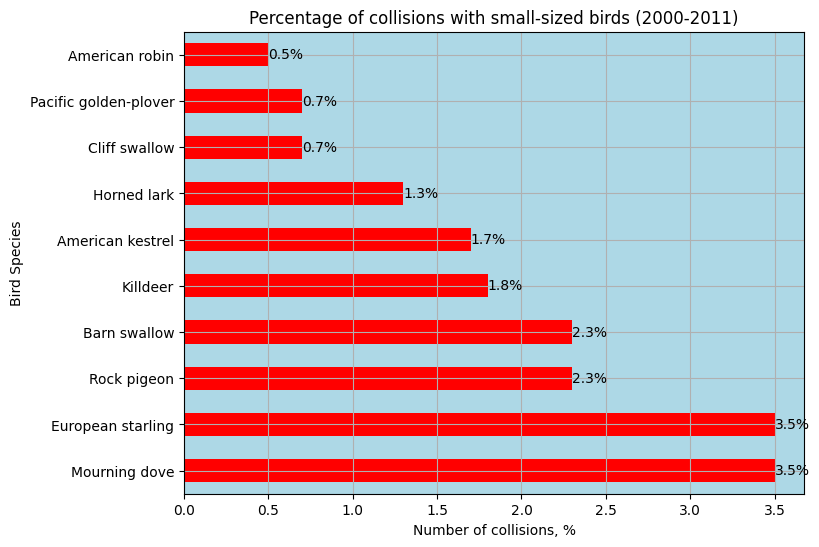

In [16]:
# Percentage of Collision by Bird Species.
# small:
# Without 'Unknown bird - small'.
Birds_type_s=Mask_size_s.loc[df_bird_strikes.WildlifeSpecies != 'Unknown bird - small']

plt.figure(figsize=(8, 6))
Birds_type = (Birds_type_s
 .groupby ('WildlifeSpecies')
 ['RecordID']
 .count().sort_values(ascending=False)/25429*100)
Birds_type_r = Birds_type.round(1).head (10)

Birds_type_r.plot.barh(color='red', grid = 'True', ylabel='Bird Species', xlabel='Number of collisions, %', title = "Percentage of collisions with small-sized birds (2000-2011)")

# Add labels to the bars
for index, value in enumerate(Birds_type_r):
    plt.text(value, index, str(value) + '%', va='center')
plt.gca().set_facecolor('lightblue')

print (Birds_type_r);

WildlifeSpecies
Red-tailed hawk        1.6
Ring-billed gull       0.9
Herring gull           0.8
Mallard                0.6
American crow          0.3
Northern pintail       0.2
Unknown bird or bat    0.2
California gull        0.1
Peregrine falcon       0.1
Gulls                  0.1
Name: RecordID, dtype: float64


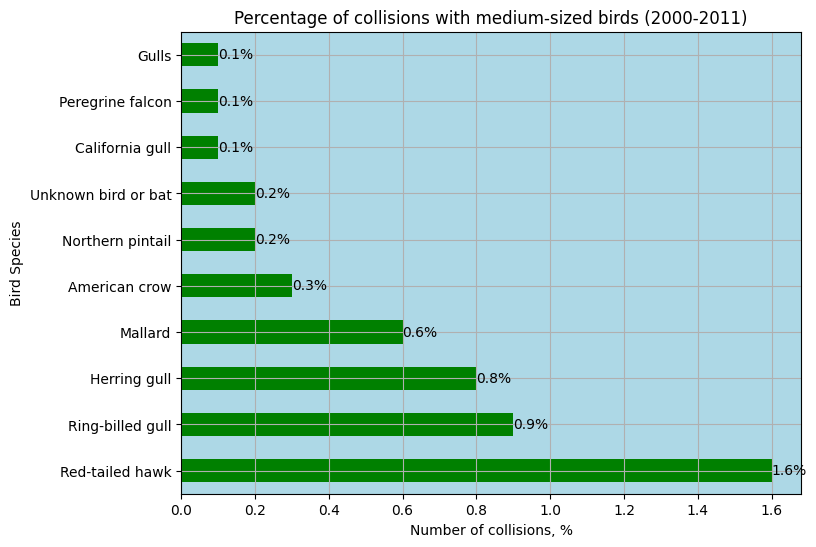

In [17]:
# medium:
# Without 'Unknown bird - medium'.
Birds_type_m=Mask_size_m.loc[df_bird_strikes.WildlifeSpecies != 'Unknown bird - medium']

plt.figure(figsize=(8, 6))
Birds_type1 = (Birds_type_m
 .groupby ('WildlifeSpecies')
 ['RecordID']
 .count().sort_values(ascending=False)/25429*100)
Birds_type_r1 = Birds_type1.round(1).head (10)

Birds_type_r1.plot.barh(color='green', grid = 'True', ylabel='Bird Species', xlabel='Number of collisions, %', title = "Percentage of collisions with medium-sized birds (2000-2011)")

# Add labels to the bars
for index, value in enumerate(Birds_type_r1):
    plt.text(value, index, str(value) + '%', va='center')
plt.gca().set_facecolor('lightblue')

print (Birds_type_r1);

WildlifeSpecies
Canada goose         1.5
Turkey vulture       0.7
White-tailed deer    0.3
Great blue heron     0.3
Osprey               0.2
Coyote               0.2
Bald eagle           0.2
Sandhill crane       0.2
Black vulture        0.1
Snow goose           0.1
Name: RecordID, dtype: float64


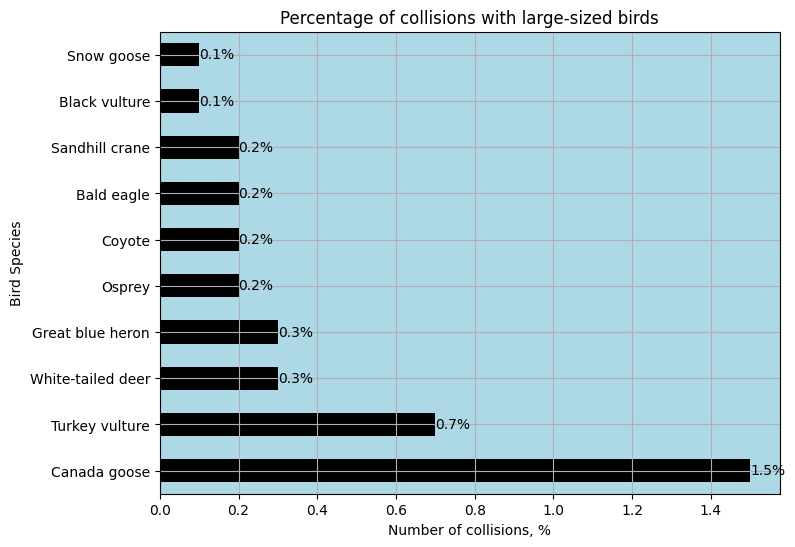

In [18]:
# large:
# Without 'Unknown bird - large'.
Birds_type_l=Mask_size_l.loc[df_bird_strikes.WildlifeSpecies != 'Unknown bird - large']

plt.figure(figsize=(8, 6))
Birds_type2 = (Birds_type_l
 .groupby ('WildlifeSpecies')
 ['RecordID']
 .count().sort_values(ascending=False)/25429*100)
Birds_type_r2 = Birds_type2.round(1).head (10)

Birds_type_r2.plot.barh(color='black', grid = 'True', ylabel='Bird Species', xlabel='Number of collisions, %', title = "Percentage of collisions with large-sized birds")

# Add labels to the bars
for index, value in enumerate(Birds_type_r2):
    plt.text(value, index, str(value) + '%', va='center')
plt.gca().set_facecolor('lightblue')

print (Birds_type_r2);

(1)-->The Canada goose (Branta canadensis) is a large wild goose with a black head and neck, white cheeks, white under its chin, and a brown body. It is native to the arctic and temperate regions of North America, and it is occasionally found during migration across the Atlantic in northern Europe.

Canada geese range from 75 to 110 cm (30 to 43 in) in length and have a 127-185 cm (50-73 in) wingspan.

The male Canada goose usually weighs 2.6-6.5 kg, averaging amongst all subspecies 3.9 kg. The female looks virtually identical, but is slightly lighter at 2.4-5.5 kg, averaging amongst all subspecies 3.6 kg, and generally 10% smaller in linear dimensions than the male counterparts.

Canada geese are known for their seasonal migrations. Their autumn migration can be seen from September to the beginning of November. The calls overhead from large groups of Canada geese flying in a V-shaped formation signal the transitions into spring and autumn. The V formation possibly improves the efficiency of flying birds, particularly over long migratory routes. This allows the birds after to take the upwash lift force due to the wingtip vortices at the tip of the wings of the lead bird.

Canada geese fly in a distinctive V-shaped flight formation, with an altitude of 1 km (3,000 feet) for migration flight. The maximum flight ceiling of Canada geese is unknown, but they have been reported at 9 km (29,000 feet).

Canada geese have been implicated in a number of bird strikes by aircraft. Their large size and tendency to fly in flocks may exacerbate their impact. In the US, the Canada goose is the second-most damaging bird strike to airplanes, with the most damaging being turkey vultures. Canada geese can cause fatal crashes when they strike an aircraft's engine. The FAA (Federal Aviation Administration) has reported 1,772 known civil aircraft strikes within the United States between 1990 and 2018. The total cost of these bird strikes to general and commercial aviation has been reported to exceed $130 million.

In [19]:
# Effect: The effect of the bird strike on the aircraft, indicating whether it caused any damage or not.
Effect_size = ((df_bird_strikes
 .groupby (['Effect'])
 ['RecordID']
 .count()
 .sort_values (ascending=False)
 .head(15))/(25429-23351)*100)
print (Effect_size)
print ()
print();

# Damage: A description of the damage caused by the bird strike.
Damage_size = ((df_bird_strikes
 .groupby (['Damage'])
 ['RecordID']
 .count()
 .sort_values (ascending=False)
 .head(15))/25429*100)
print (Damage_size)
print ()
print();

# Engines: The number of engines on the aircraft involved in the bird strike.
Engines_size = ((df_bird_strikes
 .groupby (['Engines'])
 ['RecordID']
 .count()
 .sort_values (ascending=False)
 .head(15))/(25429-234)*100)
print (Engines_size)
print ()
print();

# Cost: The cost incurred as a result of the bird strike (e.g., financial cost to repair damage or related expenses, usually in monetary value like 30,736).
Cost_size = (df_bird_strikes
 .groupby (['Cost'])
 ['RecordID']
 .count()
 .sort_values (ascending=False)
 .head(15))
print (Cost_size)
print ()
print();

# PeopleInjured: The number of people injured as a result of the bird strike.
People_size = ((df_bird_strikes
 .groupby (['PeopleInjured'])
 ['RecordID']
 .count()
 .sort_values (ascending=False)
 .head(15))/25429*100)
print (People_size)
print ()
print();


Effect
Precautionary Landing    53.946102
Aborted Take-off         23.051011
Other                    18.768046
Engine Shut Down          4.234841
Name: RecordID, dtype: float64


Damage
No damage        90.349601
Caused damage     9.650399
Name: RecordID, dtype: float64


Engines
2    91.295892
1     4.921611
3     2.238539
4     1.539988
C     0.003969
Name: RecordID, dtype: float64


Cost
0.0      24215
53.0        17
200.0       17
205.0       11
308.0       10
103.0        9
513.0        9
325.0        9
316.0        9
211.0        8
100.0        8
500.0        8
570.0        7
527.0        6
50.0         6
Name: RecordID, dtype: int64


PeopleInjured
0    99.948877
1     0.035393
2     0.011798
6     0.003933
Name: RecordID, dtype: float64


